In [23]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import re

In [20]:
import matplotlib.pyplot as plt

def plot_top_entities_side_by_side(df, id_column, condition_column, drug_column, save=True, save_path="./viz", top_n=20, color_code='#E69F00', viz_name_suffix='preclinical', save_to="png", custom_fontsize=16):
    df = df[(df[condition_column].notna()) & (df[condition_column] != '')]
    df = df[(df[drug_column].notna()) & (df[drug_column] != '')]
    
    # Group by conditions and count unique IDs
    condition_counts = (
        df.groupby(condition_column)[id_column]
        .nunique()
        .reset_index()
        .rename(columns={id_column: 'Count'})
        .sort_values(by='Count', ascending=False)
        .head(top_n)
    )
    
    # Group by drugs and count unique IDs
    drug_counts = (
        df.groupby(drug_column)[id_column]
        .nunique()
        .reset_index()
        .rename(columns={id_column: 'Count'})
        .sort_values(by='Count', ascending=False)
        .head(top_n)
    )
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

    # Plot conditions
    axes[0].barh(condition_counts[condition_column], condition_counts['Count'], color=color_code, zorder=2)
    axes[0].set_title(f'Top {top_n} Conditions by {id_column} Count', fontsize=custom_fontsize)
    axes[0].set_xlabel('Studies Count', fontsize=custom_fontsize)
    #axes[0].set_ylabel('Conditions')
    axes[0].invert_yaxis()
    for i, v in enumerate(condition_counts['Count']):
        axes[0].text(v + 0.1, i, str(v), va='center', fontsize=custom_fontsize)
        
    axes[0].tick_params(axis='both', labelsize=custom_fontsize)
    axes[0].grid(axis='x', linestyle='--', alpha=0.4, color='gray', zorder=0)
    # Set x-axis limit: from 0 to max + 0.1
    axes[0].set_xlim(0, condition_counts['Count'].max()*1.19)
    # Plot drugs
    axes[1].barh(drug_counts[drug_column], drug_counts['Count'], color=color_code, zorder=2)
    axes[1].set_title(f'Top {top_n} Drugs by {id_column} Count', fontsize=custom_fontsize)
    axes[1].set_xlabel('Studies Count', fontsize=custom_fontsize)
    #axes[1].set_ylabel('Drugs')
    axes[1].invert_yaxis()
    for i, v in enumerate(drug_counts['Count']):
        axes[1].text(v + 0.1, i, str(v), va='center', fontsize=custom_fontsize)
        
    axes[1].tick_params(axis='both', labelsize=custom_fontsize)
    axes[1].grid(axis='x', linestyle='--', alpha=0.4, color='gray', zorder=0)
    # Set x-axis limit: from 0 to max + 0.1
    axes[1].set_xlim(0, drug_counts['Count'].max()*1.19)
    # Adjust layout
    plt.tight_layout()
    if save:
        plt.savefig(f"{save_path}/top_{top_n}_drug_disease_distr_{viz_name_suffix}.{save_to}")
    plt.show()

In [6]:
FILE_PRECLINICAL_LINKING = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv"
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/data/animal_studies/full_pubmed_filtered_animal_6002827_metadata.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"

#FILE_CLINICAL_LINKING = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_clin.csv"
#FILE_CLINICAL_METADATA = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/06_preclin_clinic_join/data/clinical/clinical_nct_docs_metadata_20240313.csv"

FILE_CLINICAL_LINKING = "/scratch/sdonev/Clinical_Pipeline/data/linked_to_ontologies/entities_drug_disease_clin.csv"
FILE_CLINICAL_METADATA = "/scratch/sdonev/Clinical_Pipeline/data/raw_aact/mv_interventional_drug_studies_20260222.csv"

In [9]:
conditions_col_to_use = "merged_mondo_label" # #"linkbert_mapped_conditions" # disease_term_mondo_norm
drugs_col_to_use =  "merged_umls_label" #"linkbert_mapped_drugs" #"drug_term_umls_norm"

conditions_col_to_use_clinical =  "merged_mondo_label"#"linkbert_aact_mapped_conditions" #"disease_term_mondo_norm"
drugs_col_to_use_clinical =  "merged_umls_label" #"linkbert_aact_mapped_drugs" # "drug_term_umls_norm"

In [10]:
preclinical_df = pd.read_csv(FILE_PRECLINICAL_LINKING)
print(f"Shape of preclinical_df: {preclinical_df.shape}, {preclinical_df.PMID.nunique()} unique PMIDs")
metadata_df_year = pd.read_csv(PRECLINICAL_METADATA_PATH)[['PMID','year']]
metadata_df_year = metadata_df_year.drop_duplicates(subset=['PMID'])

preclinical_df = preclinical_df.merge(metadata_df_year, on="PMID", how="left")
preclinical_df = preclinical_df.rename(columns={
    'year': 'pub_year'
})

Shape of preclinical_df: (540999, 14), 540999 unique PMIDs


In [11]:
# DISEASE
cols_to_explode = [
    conditions_col_to_use,
    "merged_mondo_termid"
    
]

for col in cols_to_explode:
    preclinical_df[col] = preclinical_df[col].astype(str).str.split("|")

preclinical_df = preclinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique disease before length filter: {preclinical_df[conditions_col_to_use].nunique()}")
#preclinical_df = preclinical_df[preclinical_df[conditions_col_to_use].fillna("").str.len() > 2]
#print(f"Unique disease: {preclinical_df[conditions_col_to_use].nunique()}")

# DRUG
cols_to_explode = [
    drugs_col_to_use,     # e.g. drug names
    "merged_umls_termid",             # IDs
    
]

for col in cols_to_explode:
    preclinical_df[col] = preclinical_df[col].astype(str).str.split("|")

preclinical_df = preclinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique drugs before length filter: {preclinical_df[drugs_col_to_use].nunique()}")

preclinical_df = preclinical_df[preclinical_df[drugs_col_to_use].fillna("").str.len() > 2]
print(f"Unique drugs: {preclinical_df[drugs_col_to_use].nunique()}")

preclinical_df = preclinical_df.drop_duplicates()

# Strip whitespace and convert to lowercase
preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.strip().str.lower()
preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.strip().str.lower()

Unique disease before length filter: 79918
Unique drugs before length filter: 292514
Unique drugs: 291465


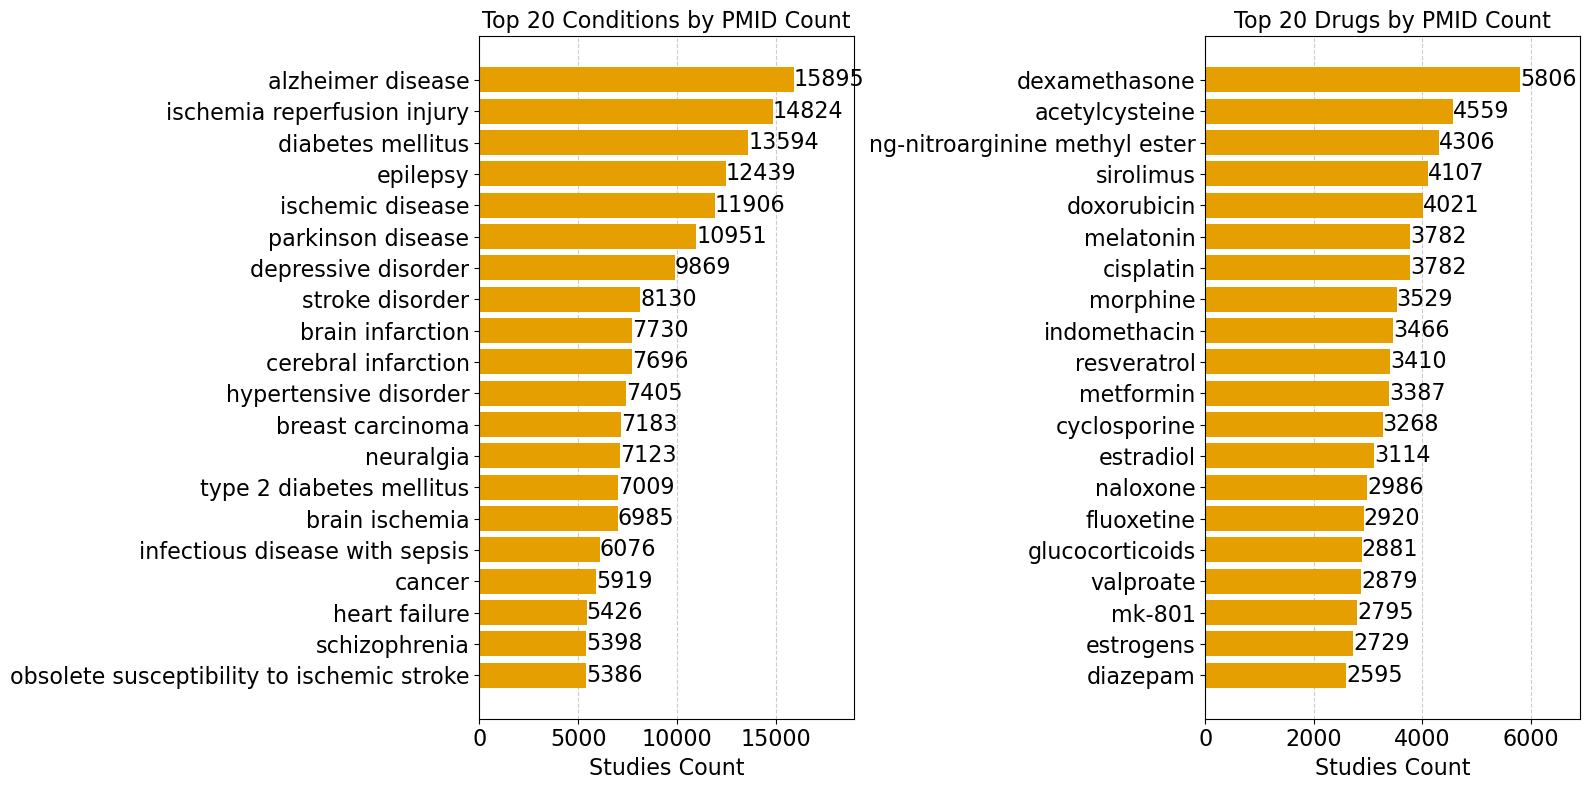

In [15]:
plot_top_entities_side_by_side(preclinical_df, "PMID", conditions_col_to_use, drugs_col_to_use)

In [12]:
# --- Load Clinical Data ---
clinical_df = pd.read_csv(FILE_CLINICAL_LINKING)
print(f"Shape of clinical_df: {clinical_df.shape}, {clinical_df.nct_id.nunique()} unique NCTIDs")

# DISEASE
cols_to_explode = [
    conditions_col_to_use_clinical,
    "merged_mondo_termid"
    
]

for col in cols_to_explode:
    clinical_df[col] = clinical_df[col].astype(str).str.split("|")

clinical_df = clinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique disease before length filter: {clinical_df[conditions_col_to_use_clinical].nunique()}")

# DRUG
cols_to_explode = [
    drugs_col_to_use_clinical,     # e.g. drug names
    "merged_umls_termid",             # IDs
]

for col in cols_to_explode:
    clinical_df[col] = clinical_df[col].astype(str).str.split("|")

clinical_df = clinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique drugs before length filter: {clinical_df[drugs_col_to_use_clinical].nunique()}")
clinical_df = clinical_df[clinical_df[drugs_col_to_use_clinical].fillna("").str.len() > 2]
print(f"Unique drugs: {clinical_df[drugs_col_to_use_clinical].nunique()}")

# Strip whitespace and convert to lowercase
clinical_df[conditions_col_to_use_clinical] = clinical_df[conditions_col_to_use_clinical].str.strip().str.lower()
clinical_df[drugs_col_to_use_clinical] = clinical_df[drugs_col_to_use_clinical].str.strip().str.lower()


Shape of clinical_df: (293949, 17), 293949 unique NCTIDs
Unique disease before length filter: 193423
Unique drugs before length filter: 249883
Unique drugs: 248935


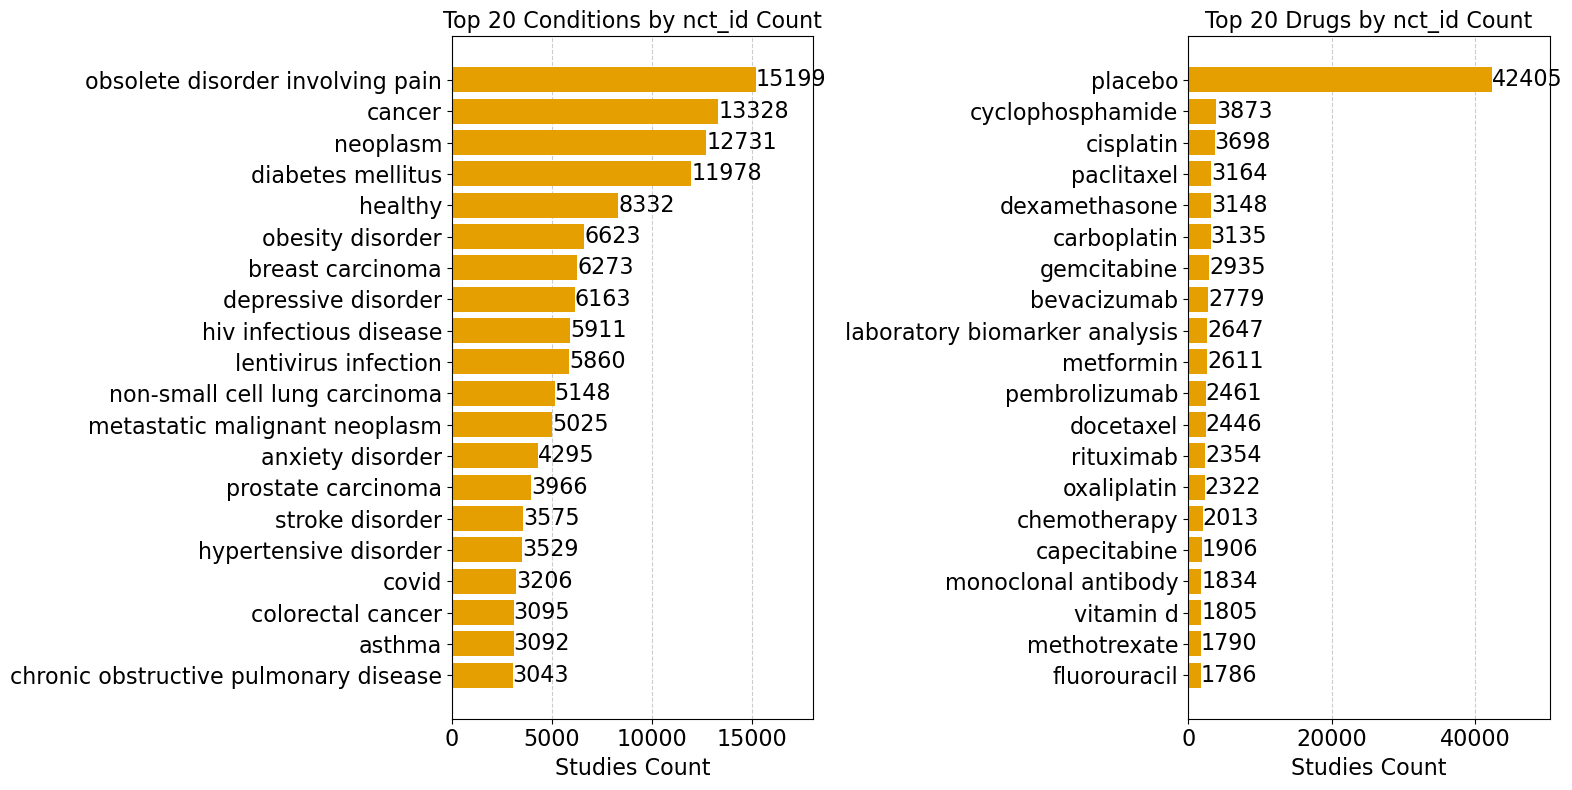

In [17]:
plot_top_entities_side_by_side(clinical_df, "nct_id", conditions_col_to_use, drugs_col_to_use)

# filter Neuro conditions

In [21]:
neuro = pd.read_csv("./data/list_neuro_conditions.csv")
disease_terms = (
    neuro["disease_mondo_term_norm"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
)

terms_set = set(disease_terms)
terms_list = list(terms_set)

In [24]:
terms = sorted({
    t.strip().lower()
    for t in terms_list
    if isinstance(t, str) and t.strip()
}, key=len, reverse=True)

# Prepare text column once
s = (
    preclinical_df["merged_mondo_label"]
    .fillna("")
    .astype(str)
    .str.lower()
)

mask = np.zeros(len(s), dtype=bool)

chunk_size = 500  # adjust if needed

for i in tqdm(range(0, len(terms), chunk_size)):
    chunk_terms = terms[i:i+chunk_size]
    pattern = re.compile("|".join(map(re.escape, chunk_terms)))
    mask |= s.str.contains(pattern, na=False).to_numpy()

preclinical_neuro = preclinical_df[mask]

preclinical_neuro.shape

100%|██████████| 20/20 [07:33<00:00, 22.68s/it]


(811300, 15)

In [25]:
s = (
    clinical_df["merged_mondo_label"]
    .fillna("")
    .astype(str)
    .str.lower()
)

mask = np.zeros(len(s), dtype=bool)

chunk_size = 500  # adjust if needed

for i in tqdm(range(0, len(terms), chunk_size)):
    chunk_terms = terms[i:i+chunk_size]
    pattern = re.compile("|".join(map(re.escape, chunk_terms)))
    mask |= s.str.contains(pattern, na=False).to_numpy()

clinical_neuro = clinical_df[mask]

clinical_neuro.shape

100%|██████████| 20/20 [14:40<00:00, 44.02s/it]


(373009, 17)

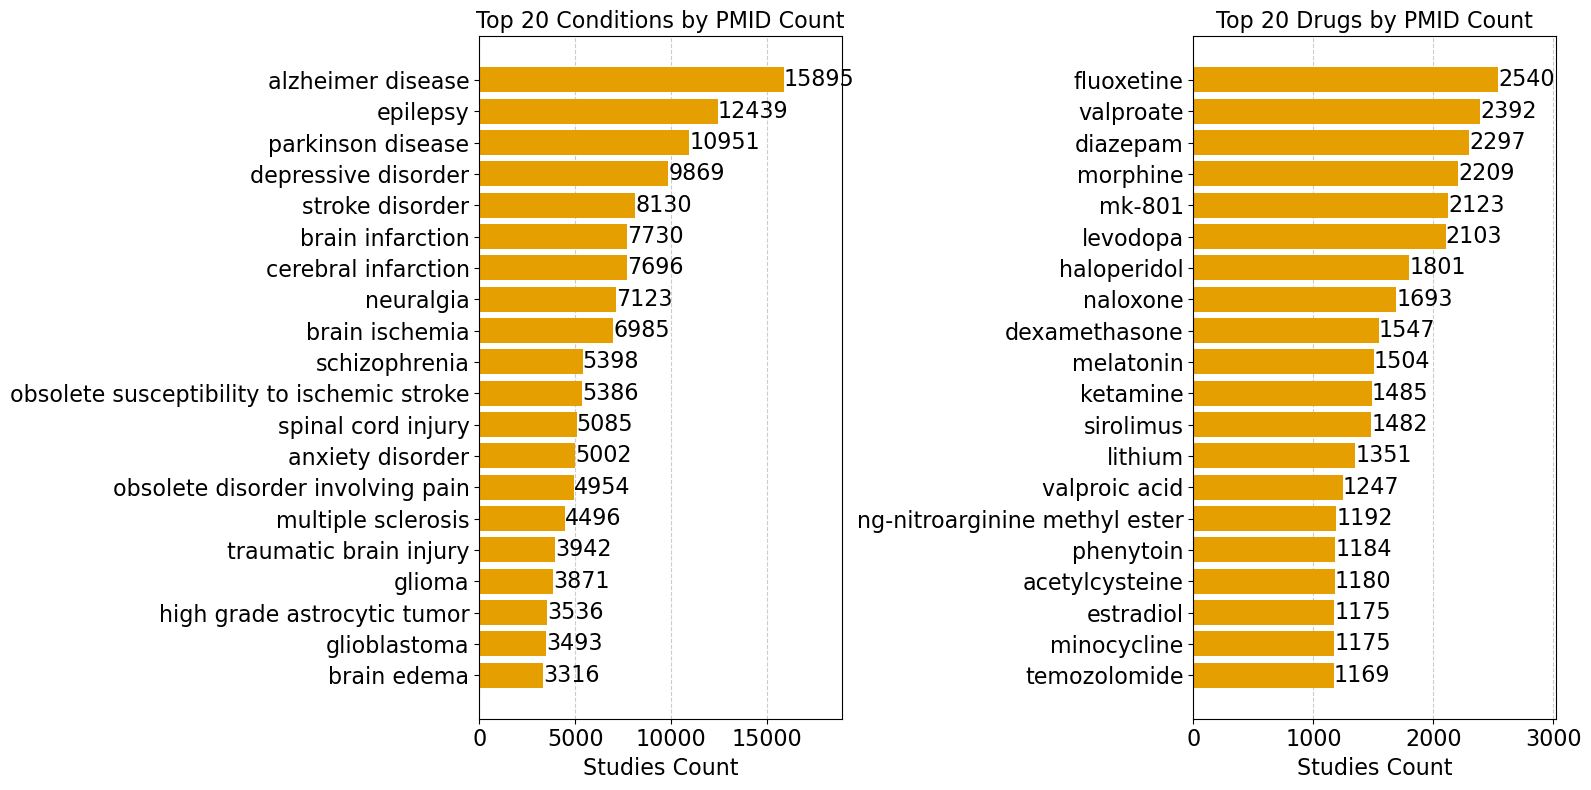

In [26]:
plot_top_entities_side_by_side(preclinical_neuro, "PMID", conditions_col_to_use, drugs_col_to_use)

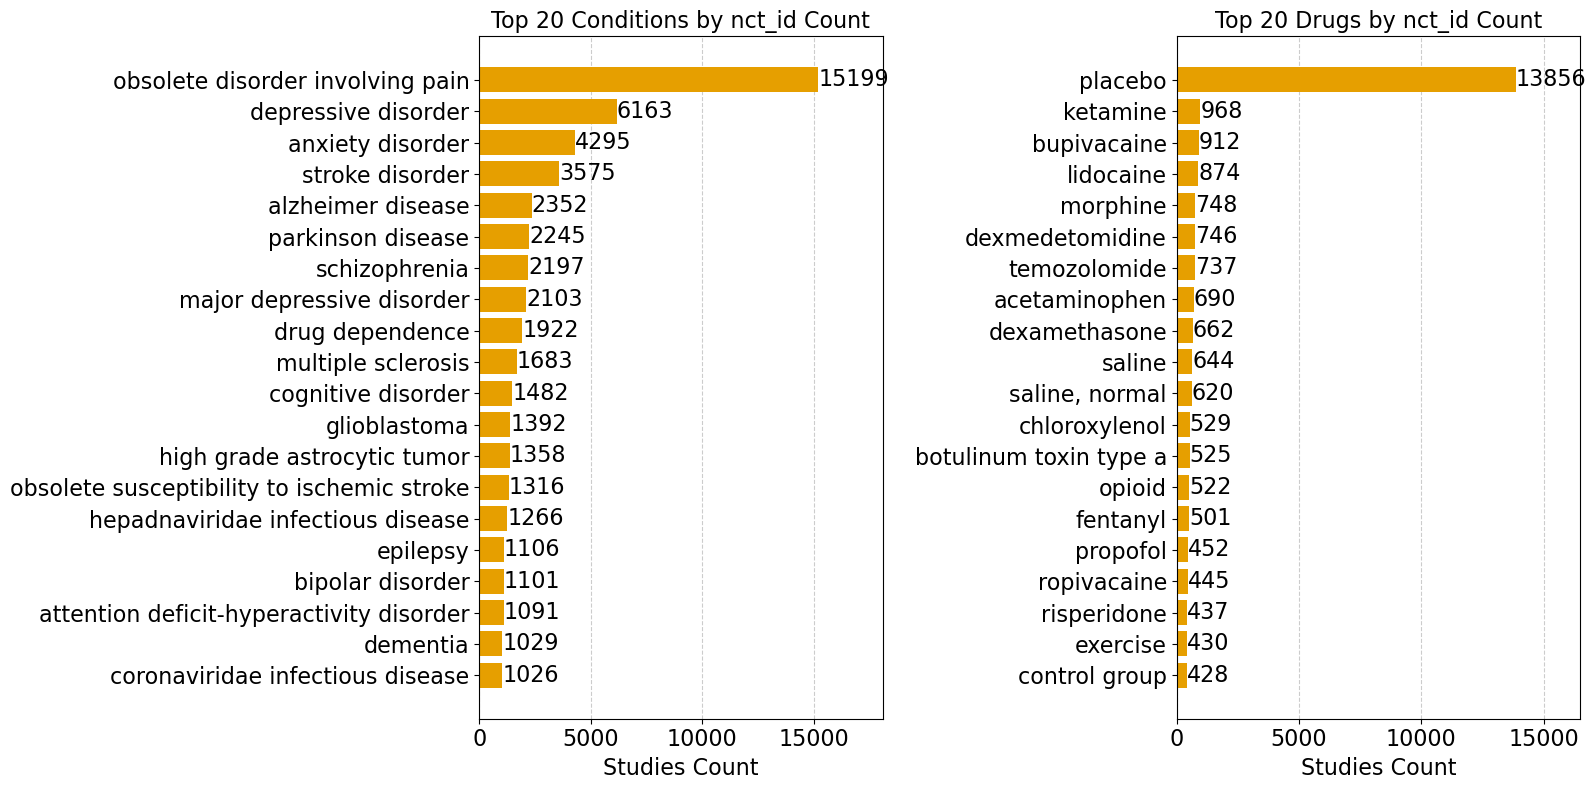

In [27]:
plot_top_entities_side_by_side(clinical_neuro, "nct_id", conditions_col_to_use, drugs_col_to_use)

In [37]:
clinical_neuro["nct_id"].nunique(), clinical_df["nct_id"].nunique()

(77758, 293075)

In [38]:
preclinical_neuro["PMID"].nunique(), preclinical_df["PMID"].nunique()

(185589, 540402)